,语言,电影数
0,"$12,000,000.00",1
1,"$170,000,000.00",1
2,"$80,000,000.00",1
3,未知,13
4,粤语,1
5,丹麦语,1
6,俄语,2
7,印地语,2
8,土耳其语,1
9,德语,4


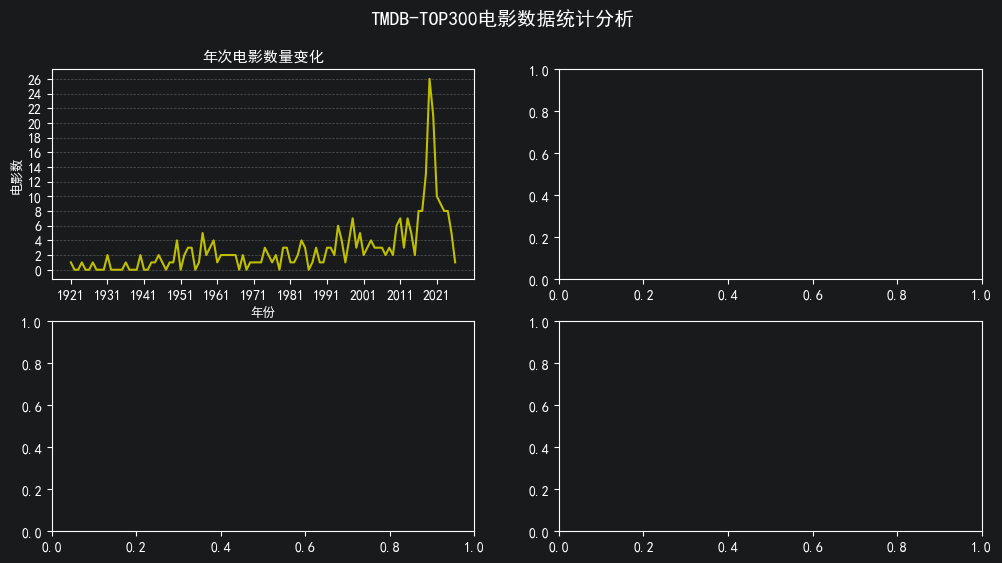

In [131]:
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import suptitle
from streamlit import title

"""
TMDB-TOP300电影数据统计分析

• 需求1：统计TOP300的电影中，每一年上映的电影数量的变化。（折线图）
• 需求2：统计对比不同语言电影数量。（柱状图）
• 需求3：统计对比不同类型电影数量。（柱状图）
• 需求4：统计对比各个电影评分的比例。（饼状图）
"""
# 读取数据源
df = pd.read_csv("../data/top_rated_movies.csv",
                 usecols=['电影名', '年份', '上映时间', '类型', '时长(m)', '评分', '语言'])
# 设置子图
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 设置中文字体
fig, axes = plt.subplots(2, 2, figsize=(12, 6), dpi=100)  # 设置子图
fig.suptitle("TMDB-TOP300电影数据统计分析", fontsize=14)  # 设置总标题
# 获取子图
axe1: Axes = axes[0, 0]  # 需求1：统计年次电影上映数量
axe2: Axes = axes[0, 1]  # 需求2：统计不同语言电影数量
axe3: Axes = axes[1, 0]  # 需求3：统计不同类型电影数量
axe4: Axes = axes[1, 1]  # 需求4：统计电影评分比例

# 需求1
# 获取数据
df_year_count = df.groupby("年份")["年份"].count()  # 获取Series数据，年份列变为了索引，值是电影数量
years = [year for year in range(df_year_count.index.min(), df1.index.max() + 1)]  # 遍历Series索引(年份)，得到年份列表
counts = [df_year_count.get(year, 0) for year in years]  # 通过年份索引，获取对应的值，得到电影数量列表
# 绘制图表
axe1.plot(years, counts, color="y")
# 设置图表
axe1.set_title("年次电影数量变化", fontsize=11)
axe1.set_xlabel("年份", fontsize=9)
axe1.set_ylabel("电影数", fontsize=9)
axe1.set_xticks(years[::10])
axe1.set_yticks([count for count in range(min(counts), max(counts) + 1, 2)])
axe1.grid(axis="y", ls="--", alpha=0.4)


# 需求2
df_lang_count = df.groupby("语言")["语言"].count().reset_index(name="电影数")
# 替换明确异常数据
df_lang_count['语言'] = df_lang_count['语言'].replace({'Cantonese': '粤语', '-': '未知'})
# 布尔遮掩码判断异常数据
mask_bad = (
    df_lang_count["语言"].isna() |
    df_lang_count["语言"].str.fullmatch(r"\$[\d,]+\.\d{2}", na=False) |
    df_lang_count["语言"].str.contains(r"\d+", na=False)
)
df_lang_count.loc[mask_bad, "语言"] = "未知"
